# Vizualize the difference of performance between AF-Cluster and AlphaConformer

In [1]:
import Pkg
Pkg.build()

┌ Warning: The active manifest file is an older format with no julia version entry. Dependencies may have been resolved with a different julia version.
└ @ nothing /store/EQUIPES/AMIG/MEMBERS/julie.daniel/AlphaConformers.jl/scripts/Manifest.toml:0
Precompiling project...
   7707.9 ms  ✓ Libgcrypt_jll
  12709.7 ms  ✓ Latexify
   4175.9 ms  ✓ XSLT_jll
   6702.4 ms  ✓ Latexify → SparseArraysExt
   7638.4 ms  ✓ UnitfulLatexify
  11681.6 ms  ✓ Qt6ShaderTools_jll
   6999.7 ms  ✓ Qt6Declarative_jll
   9910.8 ms  ✓ Qt6Wayland_jll
  49072.5 ms  ✓ Plots → UnitfulExt
  98708.2 ms  ✓ UnicodePlots
   8465.1 ms  ✓ UnicodePlots → UnitfulExt
  25118.4 ms  ✓ StatsPlots
  12 dependencies successfully precompiled in 185 seconds. 259 already precompiled.


In [3]:
using DataFrames, StatsPlots, Colors, CSV

#get the csv 
df_path="Compare_output_AF.csv"
df=DataFrames.DataFrame(CSV.File(df_path,
        comment="#", missingstring=["", "None"])) 
first(df,5)

Row,Folder,File,rmsd_apo_holo,min_apo,mean_apo,var_apo,min_holo,mean_holo,var_holo
,String31,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1AKZ,1AKZ,1.5002,0.580381,5.35266,32.8586,1.11891,5.42183,31.3812
2,1AKZ_AF_CLUSTER,1AKZ,1.5002,2.2767,13.732,58.4237,1.99558,13.6224,58.0012
3,1AKZ_AF_CLUSTER,1AKZ_U10,1.5002,0.971829,2.37733,0.526404,1.25064,2.31165,0.33791
4,1AKZ_AF_CLUSTER,1AKZ_U100,1.5002,0.49363,0.567974,0.00121571,1.23698,1.34127,0.00152258
5,1AKZ_AF_CLUSTER_template,1AKZ,1.5002,1.79782,13.5213,51.4714,1.77821,13.3829,50.2268


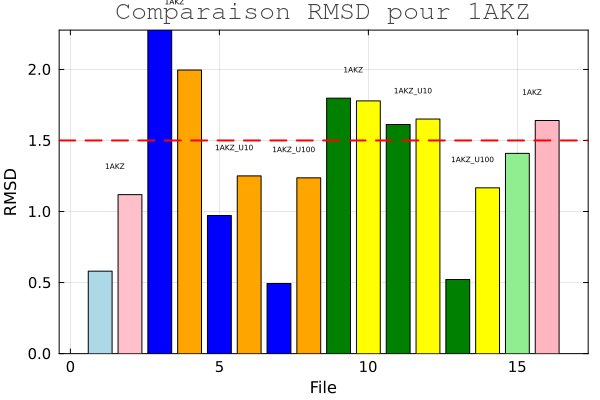

[0.580380507053322, 2.2767041228240563, 0.9718288591447389, 0.4936302216137098, 1.797815452452885, 1.6125039025251637, 0.5216507353171647, 1.4089512351189672]
Any[0.580380507053322, 1.1189051156695808, 2.2767041228240563, 1.9955810610235794, 0.9718288591447389, 1.250635858767279, 0.4936302216137098, 1.2369786969447547, 1.797815452452885, 1.7782107586183302, 1.6125039025251637, 1.6505418981391575, 0.5216507353171647, 1.1666747114903644, 1.4089512351189672, 1.6403112073471486]
[0.8652069734807323, 0.6742237495595886, 0.8121987311543943, 0.6847318320948796, 2.413315102448714, 0.8307901068473771, 0.819284341644559, 0.9512607317263369]
Any[0.8652069734807323, 0.23974488410479472, 0.6742237495595886, 0.6587307733164905, 0.8121987311543943, 0.6731290310292191, 0.6847318320948796, 0.44189028959337934, 2.413315102448714, 2.595617171760735, 0.8307901068473771, 0.6278187749121004, 0.819284341644559, 0.4898405275271358, 0.9512607317263369, 0.24257658285690673]


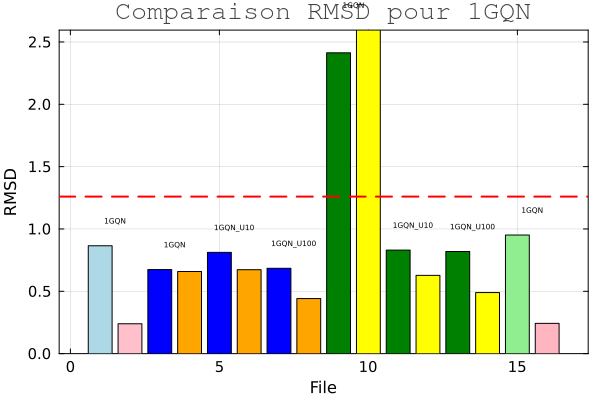

In [5]:
using DataFrames, StatsPlots, CSV

# Charger les données
df_path = "Compare_output_AF.csv"
df = DataFrame(CSV.File(df_path, comment="#", missingstring=["", "None"]))

# Trouver les noms PDB
pdb_names = ["1AKZ","1GQN"]

# Couleurs personnalisées pour chaque groupe
colors_list = [
    :lightblue,          # 1er élément
    :pink,    # 2
    :blue,    # 3
    :orange, 
    :blue,    # 3
    :orange, 
    :blue,    # 3
    :orange,        # 4
    :green,          # 5
    :yellow,      # 6
    :green,          # 5
    :yellow,  
    :green,          # 5
    :yellow,
    :lightgreen,          # 1er élément
    :lightpink           # 7
]
line_color = :red

for pdb in pdb_names
    df_subset = filter(row -> startswith(row.File, pdb), df)
    n = nrow(df_subset)
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.min_apo
    min_holo_vals = df_subset.min_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)
    all_vals=[]
    println(min_apo_vals)
    for i in 1:length(min_apo_vals)
        push!(all_vals,min_apo_vals[i])
        push!(all_vals,min_holo_vals[i])
    end
    println(all_vals)
    # Barplot simple
    p = bar(
        1:(2n),
        all_vals,
        bar_width = 0.8,
        c = colors_list[1:2n],  # Trim la liste à la bonne taille
        legend = false,
        xlabel = "File",
        ylabel = "RMSD",
        title = "Comparaison RMSD pour $pdb",
        framestyle = :box,
        titlefont = font(14, "Arial"),
        tickfont = font(10)
    )

    
    # Ligne horizontale
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotations
    for i in 1:n
        idx = 2i - 1
        val = max(min_apo_vals[i], min_holo_vals[i]) + 0.2
        annotate!(p, (idx + 0.5, val, text(labels[i], :black, 5)))
    end
    #=
    # Barres factices pour légende custom
    # Barres factices pour légende custom
    bar!(p,[NaN], [NaN], c = :lightblue, label = "min_apo AlphaConformer")
    bar!(p,[NaN], [NaN], c = :pink,      label = "min_holo AlphaConformer")
    bar!(p,[NaN], [NaN], c = :blue,      label = "min_apo AF-Cluster")
    bar!(p,[NaN], [NaN], c = :orange,    label = "min_holo AF-Cluster")
    bar!(p,[NaN], [NaN], c = :green,     label = "min_apo AF-Cluster + template")
    bar!(p,[NaN], [NaN], c = :yellow,    label = "min_holo AF-Cluster + template")
    =#


    display(p)
end


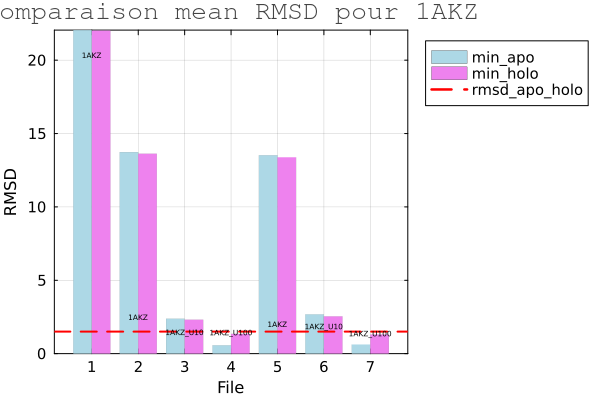

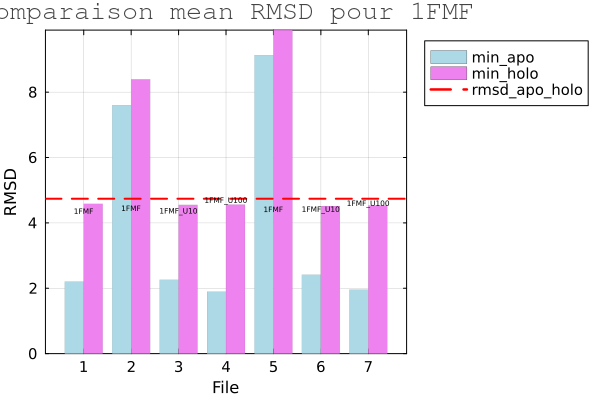

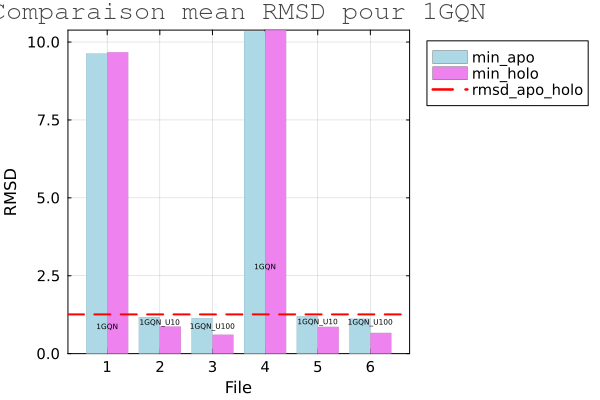

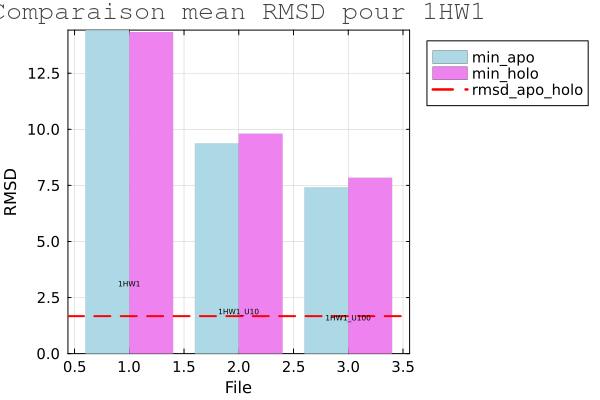

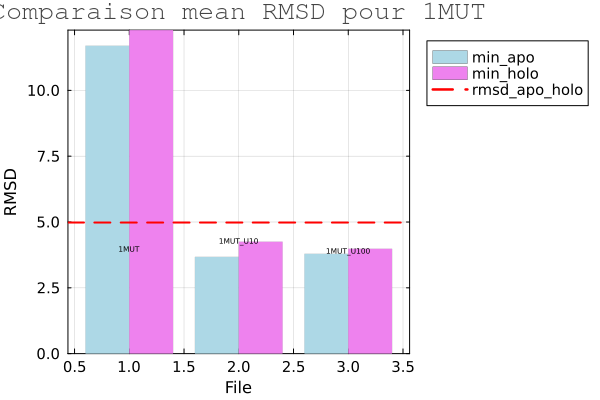

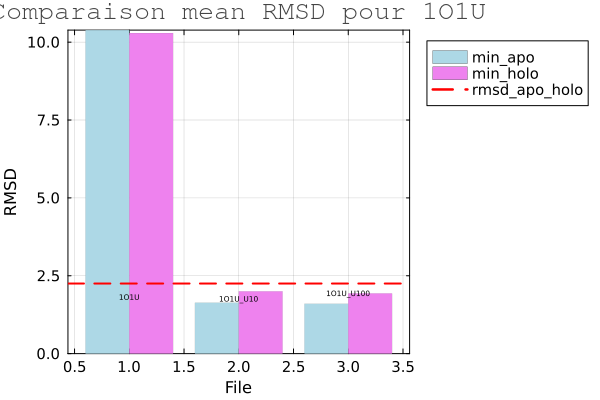

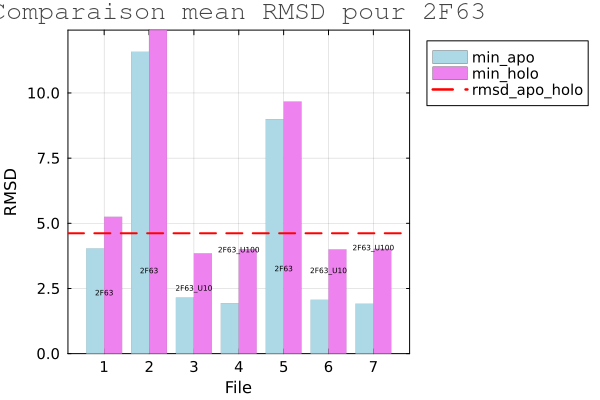

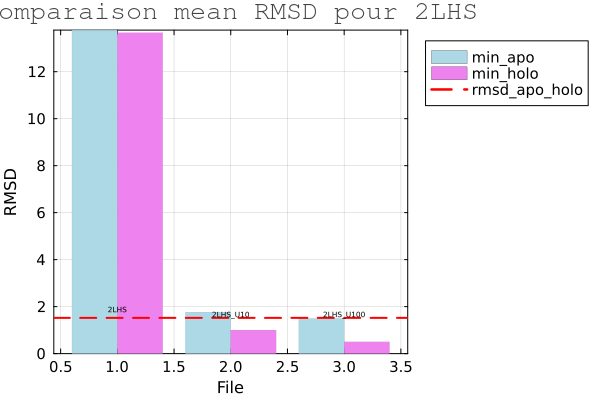

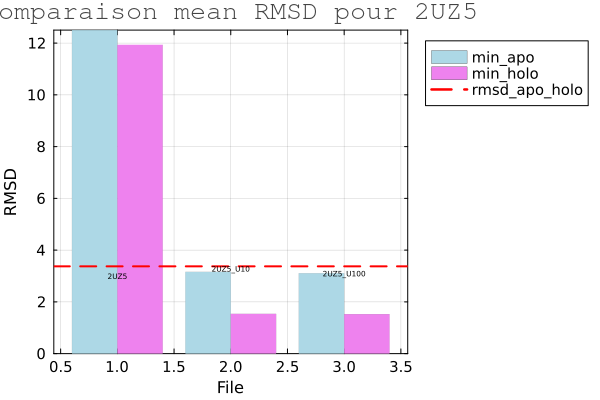

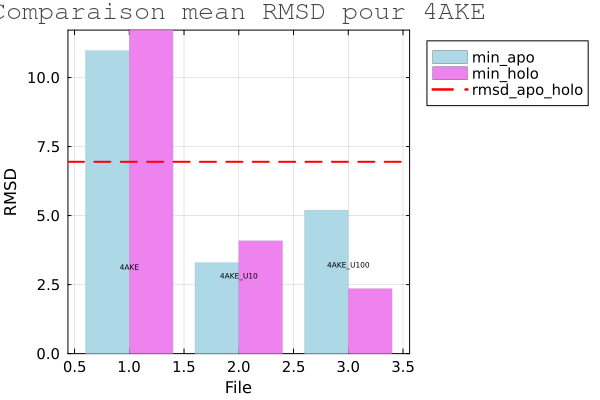

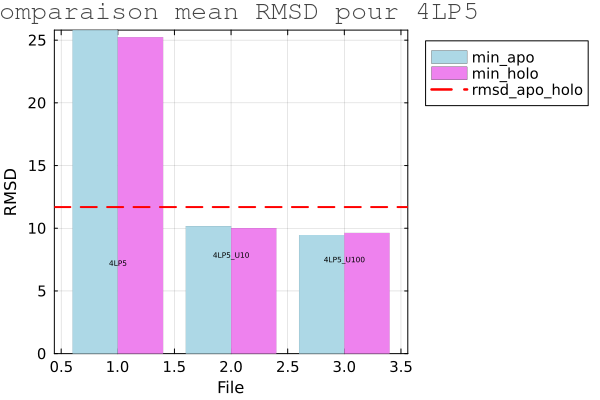

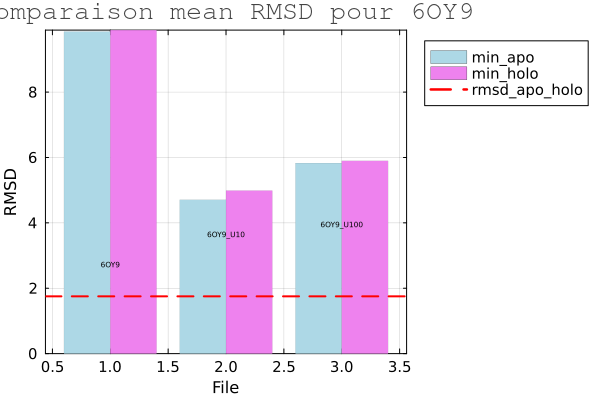

In [15]:
# Créer un graphique pour chaque PDB
for pdb in pdb_names
    # Sous-dataframe correspondant à ce PDB
    df_subset = filter(row -> startswith(row.File, pdb), df)
    # Création des données pour le barplot
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.mean_apo
    min_holo_vals = df_subset.mean_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)  # identique pour tous les row
    # Barplot groupé
    p = groupedbar(
        [min_apo_vals min_holo_vals],
        bar_position = :dodge,
        label = ["min_apo" "min_holo"],
        title = "Comparaison mean RMSD pour $pdb",
        xlabel = "File",
        ylabel = "RMSD",
        lw = 0,
        c = [apo_color holo_color],
        legend = :outertopright,
        titlefont = font(14, "Arial"),
        tickfont = font(10),
        legendfontsize = 10,
        framestyle = :box
    )

    # Ligne horizontale rouge pour rmsd_apo_holo
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotation : Folders pour chaque File
    for (i, row) in enumerate(eachrow(df_subset))
        annotate!(p, (i, max(row.min_apo, row.min_holo) + 0.2, text(row.File, :black,5)))
    end

    # Affiche ou sauvegarde
    display(p)
    # savefig(p, "rmsd_plot_$pdb.png")  # optionnel
end


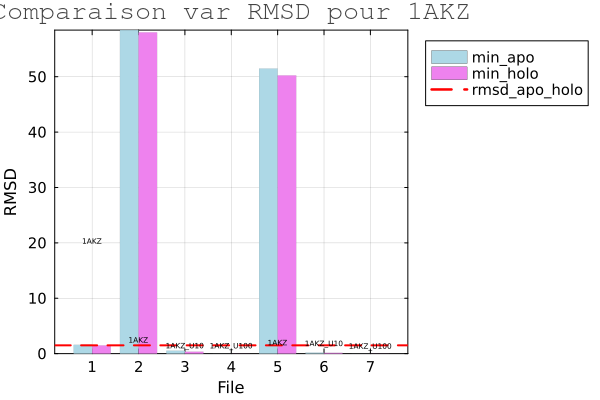

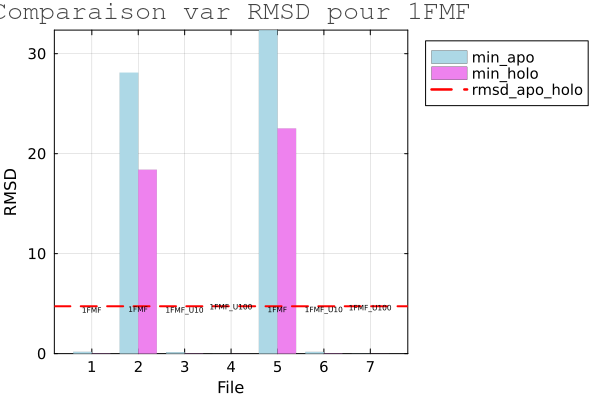

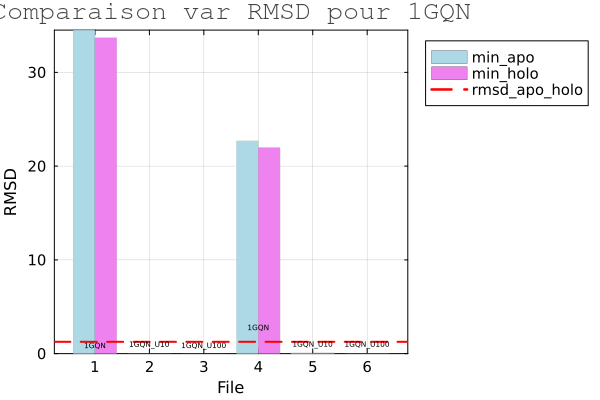

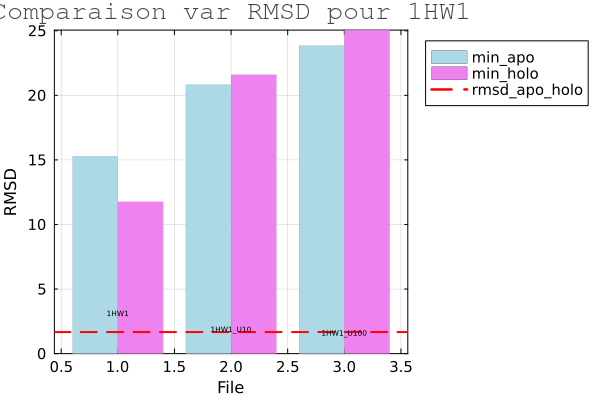

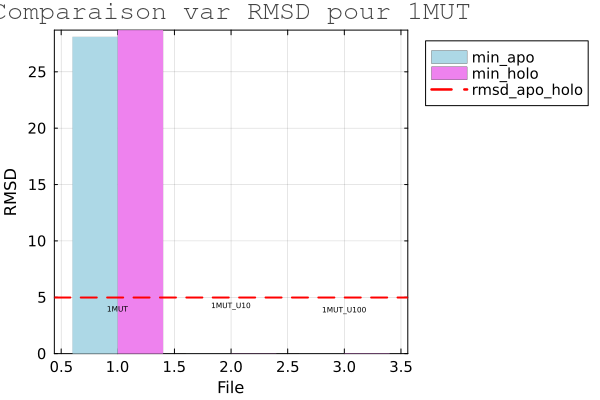

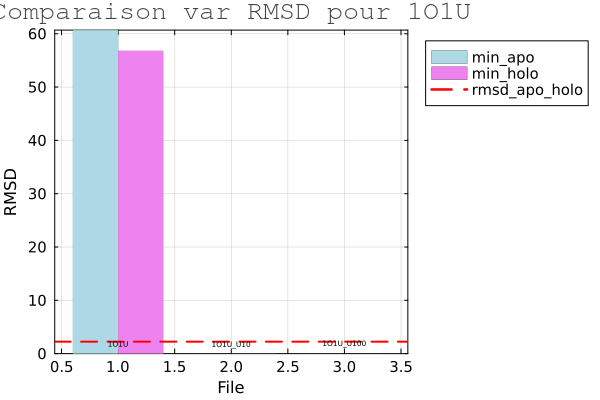

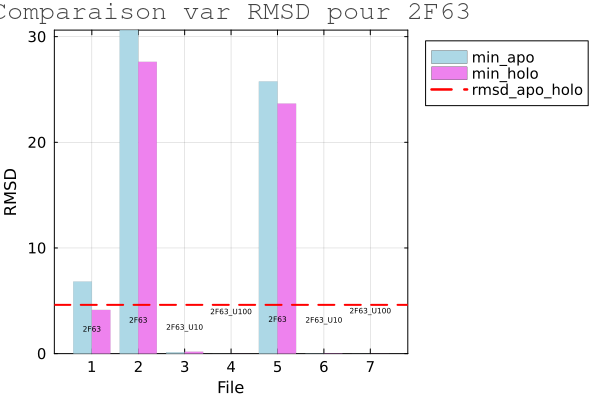

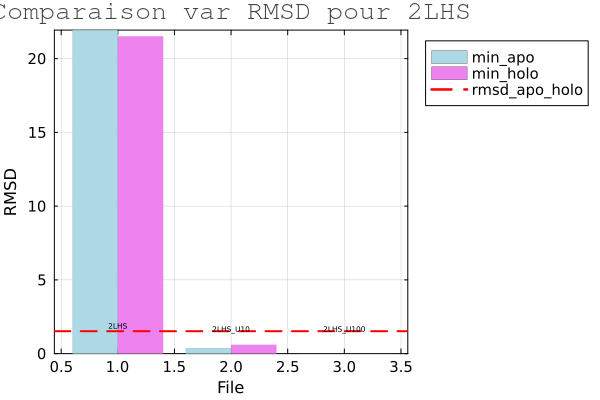

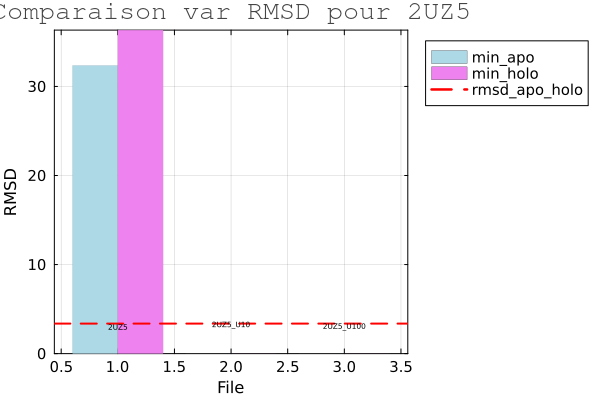

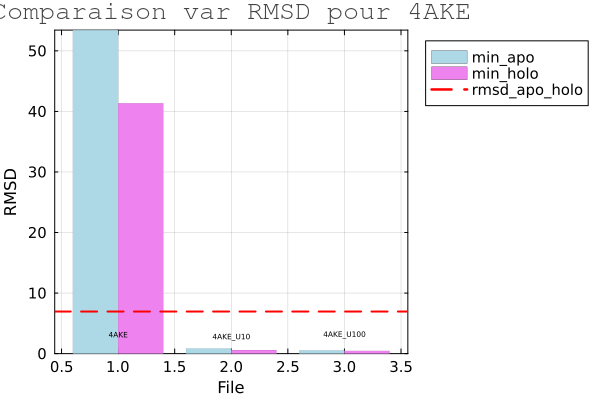

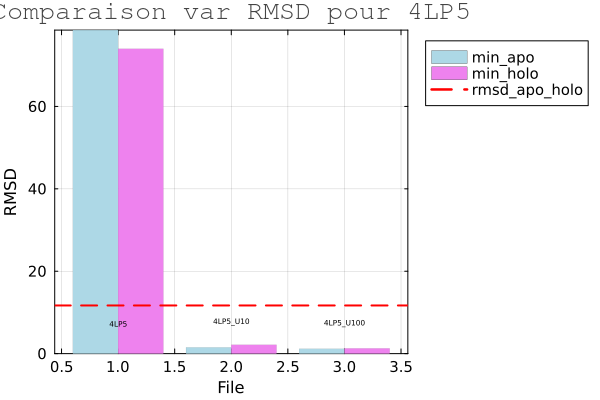

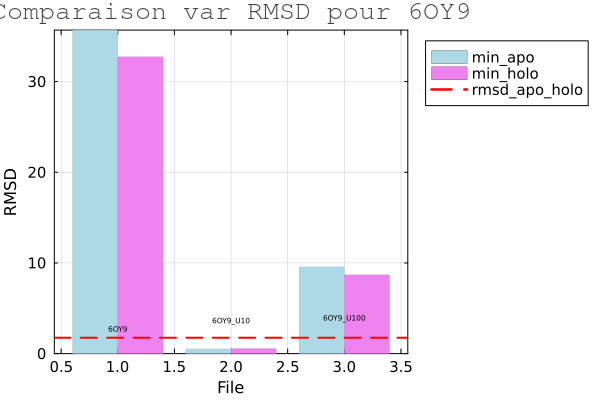

In [16]:
# Créer un graphique pour chaque PDB
for pdb in pdb_names
    # Sous-dataframe correspondant à ce PDB
    df_subset = filter(row -> startswith(row.File, pdb), df)
    # Création des données pour le barplot
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.var_apo
    min_holo_vals = df_subset.var_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)  # identique pour tous les row
    # Barplot groupé
    p = groupedbar(
        [min_apo_vals min_holo_vals],
        bar_position = :dodge,
        label = ["min_apo" "min_holo"],
        title = "Comparaison var RMSD pour $pdb",
        xlabel = "File",
        ylabel = "RMSD",
        lw = 0,
        c = [apo_color holo_color],
        legend = :outertopright,
        titlefont = font(14, "Arial"),
        tickfont = font(10),
        legendfontsize = 10,
        framestyle = :box
    )

    # Ligne horizontale rouge pour rmsd_apo_holo
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotation : Folders pour chaque File
    for (i, row) in enumerate(eachrow(df_subset))
        annotate!(p, (i, max(row.min_apo, row.min_holo) + 0.2, text(row.File, :black,5)))
    end

    # Affiche ou sauvegarde
    display(p)
    # savefig(p, "rmsd_plot_$pdb.png")  # optionnel
end
